## 1. How are coefficients affected?

In [1]:
from sklearn.datasets import make_regression

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
X, y = make_regression(n_samples=10000, n_features=5, noise=0.2, random_state=42)

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [4]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [5]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

    print(coefs)
    print(r2_scores)
        

[[91.40440501625781, 94.77487084137977, 0.27579449907943343, 38.25524254673188, 5.355840256134542]]
[0.9999978288670148]
[[91.40440501625781, 94.77487084137977, 0.27579449907943343, 38.25524254673188, 5.355840256134542], [91.29033354105725, 94.65495104971794, 0.2805231491399449, 38.205721721686174, 5.349200989581019]]
[0.9999978288670148, 0.9999961323217114]
[[91.40440501625781, 94.77487084137977, 0.27579449907943343, 38.25524254673188, 5.355840256134542], [91.29033354105725, 94.65495104971794, 0.2805231491399449, 38.205721721686174, 5.349200989581019], [90.27637125373536, 93.58918824501863, 0.32200496726448313, 37.76573841297098, 5.290175594997749]]
[0.9999978288670148, 0.9999961323217114, 0.9998412288379249]
[[91.40440501625781, 94.77487084137977, 0.27579449907943343, 38.25524254673188, 5.355840256134542], [91.29033354105725, 94.65495104971794, 0.2805231491399449, 38.205721721686174, 5.349200989581019], [90.27637125373536, 93.58918824501863, 0.32200496726448313, 37.76573841297098, 5.

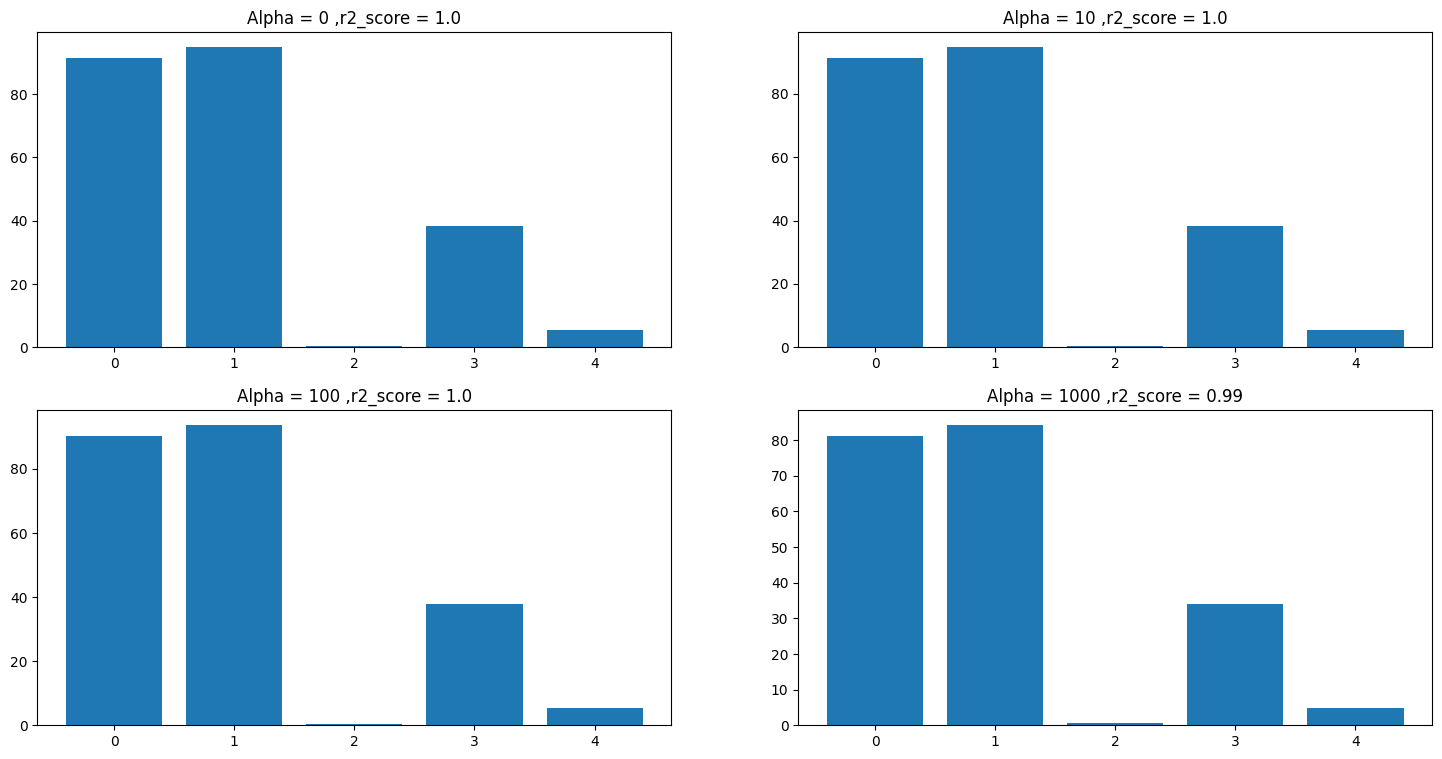

In [6]:
plt.figure(figsize=(18,9))
plt.subplot(221)
plt.bar(range(5),coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(range(5),coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(range(5),coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(range(5),coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

## 2. Higher Coefficients are affected more

In [7]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())


input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array,columns=[f"Feature {i}" for i in range(5)])
coef_df['alpha'] = alphas
coef_df.set_index('alpha').head(5)      # printing the new data while making the 'alpha' as the new index
# coef_df




,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4
alpha,,,,,
0.0000,91.404405,94.774871,0.275794,38.255243,5.355840
0.0001,91.404404,94.774870,0.275795,38.255242,5.355840
0.0010,91.404394,94.774859,0.275795,38.255238,5.355840
0.0100,91.404291,94.774751,0.275799,38.255193,5.355834
0.1000,91.403263,94.773670,0.275842,38.254747,5.355774


In [8]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [9]:
input_array = np.array(coefs).T

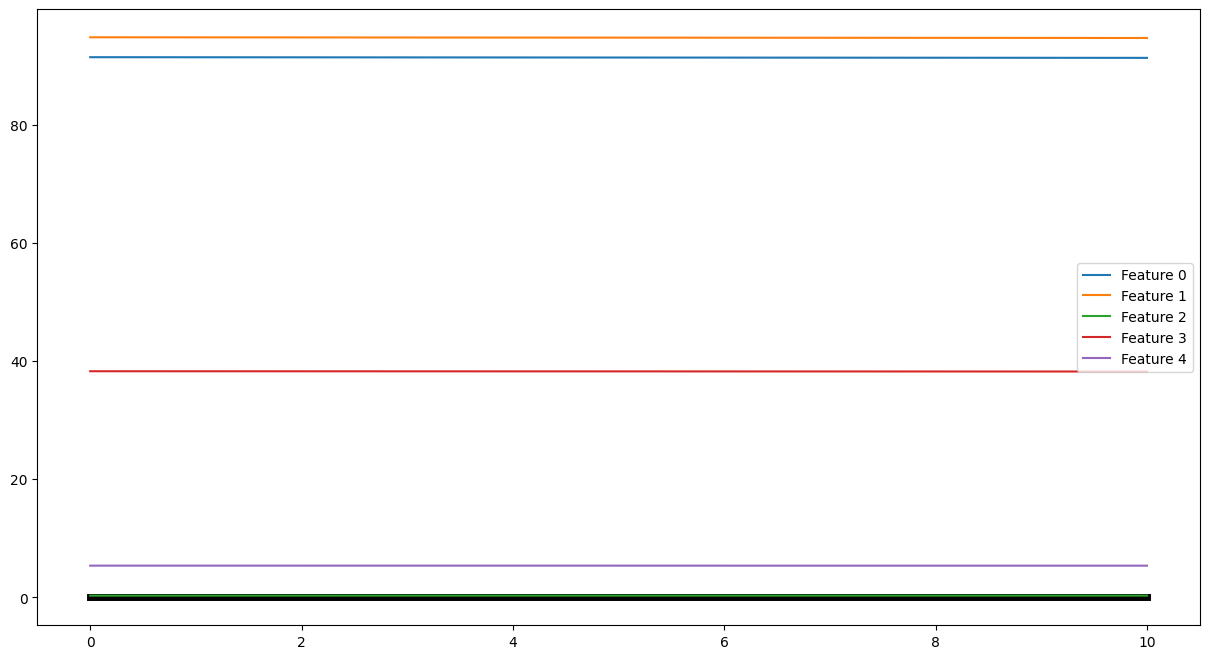

In [10]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=f"Feature {i}")
plt.legend()

## 3. Impact on Bias and Variance

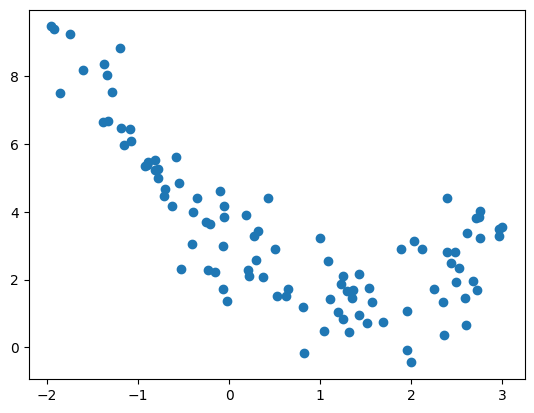

In [11]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [13]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [14]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

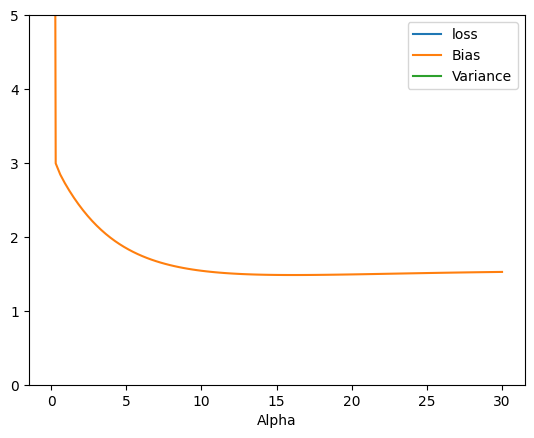

In [15]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()

## 4. Effect of Regularization on Loss Function

[27.82809103]
-2.29474455867698


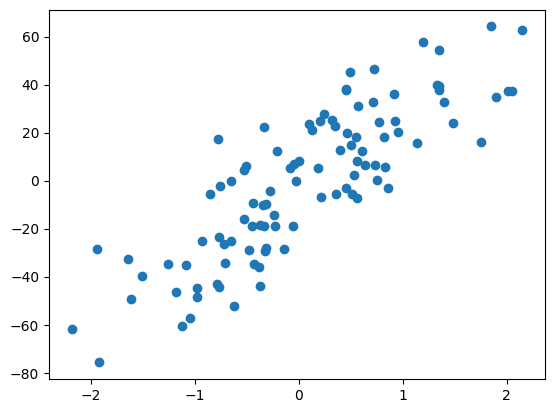

In [16]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [17]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [18]:
def predict(m):
    return m*X - 2.29

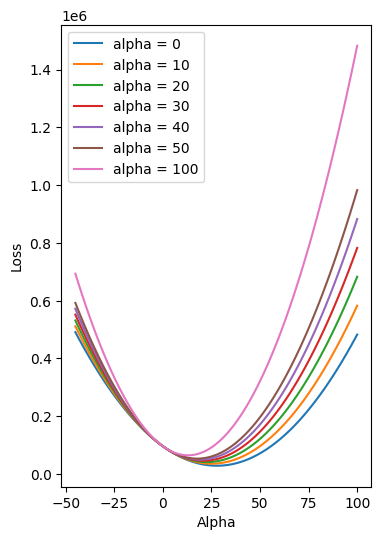

In [19]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()

### for 2 coefficients

<img src='https://explained.ai/regularization/images/lagrange-animation.gif'>